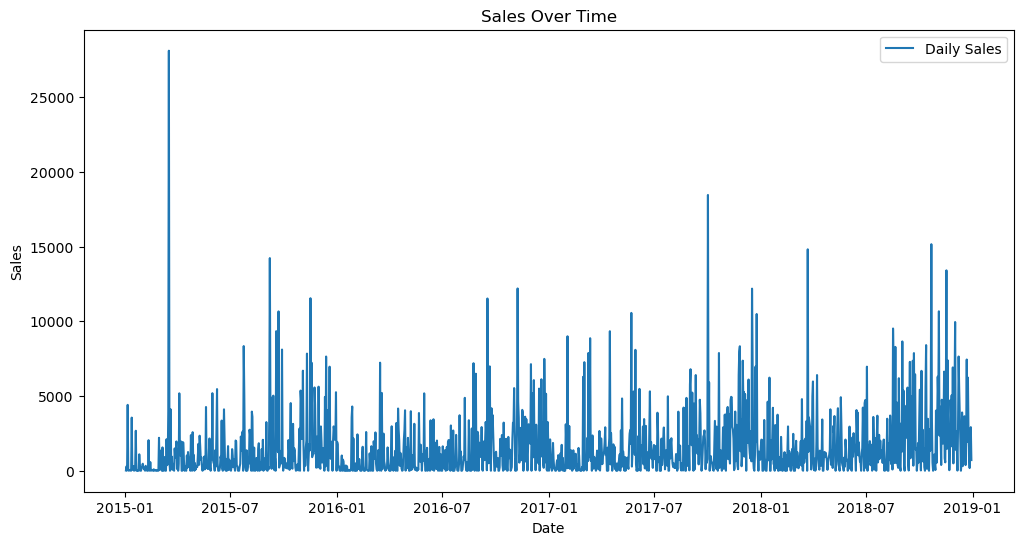

E:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


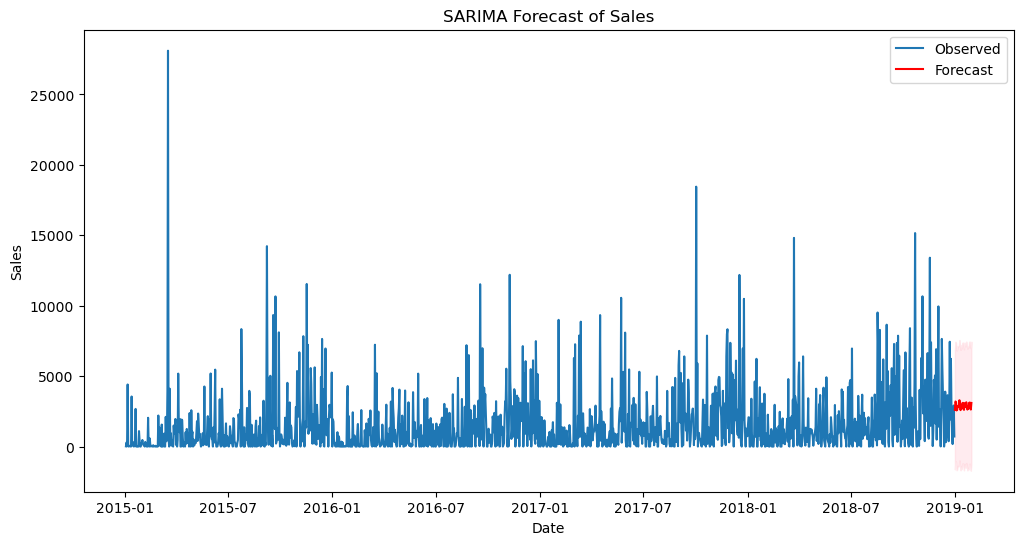

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load dataset
df = pd.read_csv("train.csv")

# Convert 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Group by date and sum sales
sales = df.groupby('Order Date')['Sales'].sum()

# Reindex with daily frequency to ensure continuity
sales = sales.asfreq('D').fillna(0)

# Plot sales over time
plt.figure(figsize=(12, 6))
plt.plot(sales, label="Daily Sales")
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# Train SARIMA model
model = SARIMAX(sales, order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit(disp=False)

# Forecast next 30 days
forecast = results.get_forecast(steps=30)
forecast_index = pd.date_range(sales.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot forecast
plt.figure(figsize=(12, 6))
plt.plot(sales, label="Observed")
plt.plot(forecast_index, forecast_mean, label="Forecast", color='red')
plt.fill_between(forecast_index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.title("SARIMA Forecast of Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()
